# Insurance Risk Analytics: Exploratory Data Analysis

## Comprehensive Analysis of Insurance Portfolio Data

This notebook performs a detailed exploratory data analysis (EDA) of insurance claim data spanning an 18-month period. The analysis covers data quality assessment, statistical summaries, univariate and bivariate analysis, geographic trends, temporal patterns, and vehicle risk profiles.

### Objectives:
1. **Data Quality**: Assess data completeness and validity
2. **Distribution Analysis**: Understand patterns in premiums, claims, and customer values
3. **Segment Analysis**: Calculate loss ratios by province, vehicle type, and demographics
4. **Risk Profiling**: Identify high-risk vehicle makes, geographic regions, and customer segments
5. **Temporal Trends**: Analyze claim patterns over the 18-month period
6. **Actionable Insights**: Provide recommendations based on findings

**Analysis Date**: May 2026  
**Dataset**: MachineLearningRating_v3.txt

## 1. Import Libraries and Load Data

In [11]:
# Import necessary libraries
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
from datetime import datetime
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Configure visualization style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

# Suppress warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis started at: 2026-05-23 23:01:09


In [14]:
import os
import sys

print("Loading insurance data...")

# Construct the correct path to the data file
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'MachineLearningRating_v3.txt'))
print(f"Looking for data at: {data_path}")

# Try different separators
separators = ['|', '\t', ',']
df = None

for sep in separators:
    try:
        df_test = pd.read_csv(data_path, sep=sep, low_memory=False)
        # Check if we got multiple columns
        if df_test.shape[1] > 1:
            df = df_test
            print(f"✓ Data loaded with '{sep}' separator!")
            break
        else:
            print(f"✗ {sep} separator resulted in {df_test.shape[1]} column")
    except Exception as e:
        print(f"✗ {sep} separator failed: {str(e)[:50]}")
        continue

if df is not None and len(df) > 0:
    print(f"\n✓ Data loaded successfully!")
    print(f"  - Shape: {df.shape}")
    print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\nDataset Overview:")
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")
    
    print(f"\nFirst 10 columns:")
    for i, col in enumerate(df.columns[:10]):
        print(f"  {i+1}. {col} ({df[col].dtype})")
    
    if len(df.columns) > 10:
        print(f"  ... and {len(df.columns)-10} more columns")
    
    print(f"\nFirst 2 rows (first 5 columns):")
    display(df.iloc[:2, :5])
else:
    print("⚠ Failed to load data with any separator")
    df = pd.DataFrame()

Loading insurance data...
Looking for data at: c:\Users\usb\Documents\Insurance-Risk-Analytics-Predictive-Modeling\data\MachineLearningRating_v3.txt
✓ Data loaded with '|' separator!

✓ Data loaded successfully!
  - Shape: (1000098, 52)
  - Memory usage: 2373.96 MB

Dataset Overview:
Rows: 1,000,098
Columns: 52

First 10 columns:
  1. UnderwrittenCoverID (int64)
  2. PolicyID (int64)
  3. TransactionMonth (object)
  4. IsVATRegistered (bool)
  5. Citizenship (object)
  6. LegalType (object)
  7. Title (object)
  8. Language (object)
  9. Bank (object)
  10. AccountType (object)
  ... and 42 more columns

First 2 rows (first 5 columns):


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship
0,145249,12827,2015-03-01 00:00:00,True,
1,145249,12827,2015-05-01 00:00:00,True,


## 2. Data Summarization and Quality Assessment

### 2.1 Data Quality Check

In [15]:
# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Value Analysis:")
print("=" * 70)
if len(missing_data) == 0:
    print("✓ No missing values detected!")
else:
    print(missing_data.to_string(index=False))
    print(f"\nHandling Strategy:")
    print("  - For numerical columns: Will use median imputation if needed")
    print("  - For categorical columns: Will use mode or create 'Unknown' category")

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

# Data type summary
print(f"\nData Type Summary:")
print(df.dtypes.value_counts())

Missing Value Analysis:
                 Column  Missing_Count  Missing_Percentage
NumberOfVehiclesInFleet        1000098              100.00
            CrossBorder         999400               99.93
    CustomValueEstimate         779642               77.96
              Converted         641901               64.18
                Rebuilt         641901               64.18
             WrittenOff         641901               64.18
             NewVehicle         153295               15.33
                   Bank         145961               14.59
            AccountType          40232                4.02
                 Gender           9536                0.95
          MaritalStatus           8259                0.83
              Cylinders            552                0.06
          cubiccapacity            552                0.06
              kilowatts            552                0.06
          NumberOfDoors            552                0.06
       VehicleIntroDate         

### 2.2 Descriptive Statistics for Numerical Columns

In [16]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")

# If no numerical columns detected, try to convert some object columns to numeric
if len(numerical_cols) == 0:
    print("\n⚠ Warning: No numerical columns detected. Attempting to convert...")
    for col in df.columns[:10]:  # Try first 10 columns
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            if df[col].notna().sum() > 0:
                numerical_cols.append(col)
                print(f"  ✓ Converted {col} to numeric")
        except:
            pass

# Ensure we have numerical columns
if len(numerical_cols) == 0:
    print("\n⚠ No numerical columns found after conversion. Using first few columns as sample...")
    numerical_cols = df.columns[:5].tolist()

# Descriptive statistics
print("\n" + "="*100)
print("DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES")
print("="*100)

if len(numerical_cols) > 0:
    desc_stats = df[numerical_cols].describe().T
    desc_stats['skewness'] = df[numerical_cols].skew()
    desc_stats['kurtosis'] = df[numerical_cols].kurtosis()
    desc_stats['cv'] = (df[numerical_cols].std() / df[numerical_cols].mean()).round(3)  # Coefficient of variation
    
    print(desc_stats.round(3).to_string())
else:
    print("Unable to compute descriptive statistics")

# Categorical columns summary
print("\n" + "="*100)
print("CATEGORICAL COLUMNS SUMMARY")
print("="*100)

for col in categorical_cols[:10]:  # Limit to first 10
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {unique_count}")
    if unique_count <= 20:
        print(f"  Top 5 values:")
        print(df[col].value_counts().head().to_string())
    else:
        print(f"  (Too many unique values: {unique_count})")

Numerical Columns (15): ['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode', 'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

Categorical Columns (36): ['TransactionMonth', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType']

DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES
                              count          mean           std          min           25%           50%          75% 

## 3. Univariate Analysis

### 3.1 Distribution of Numerical Features

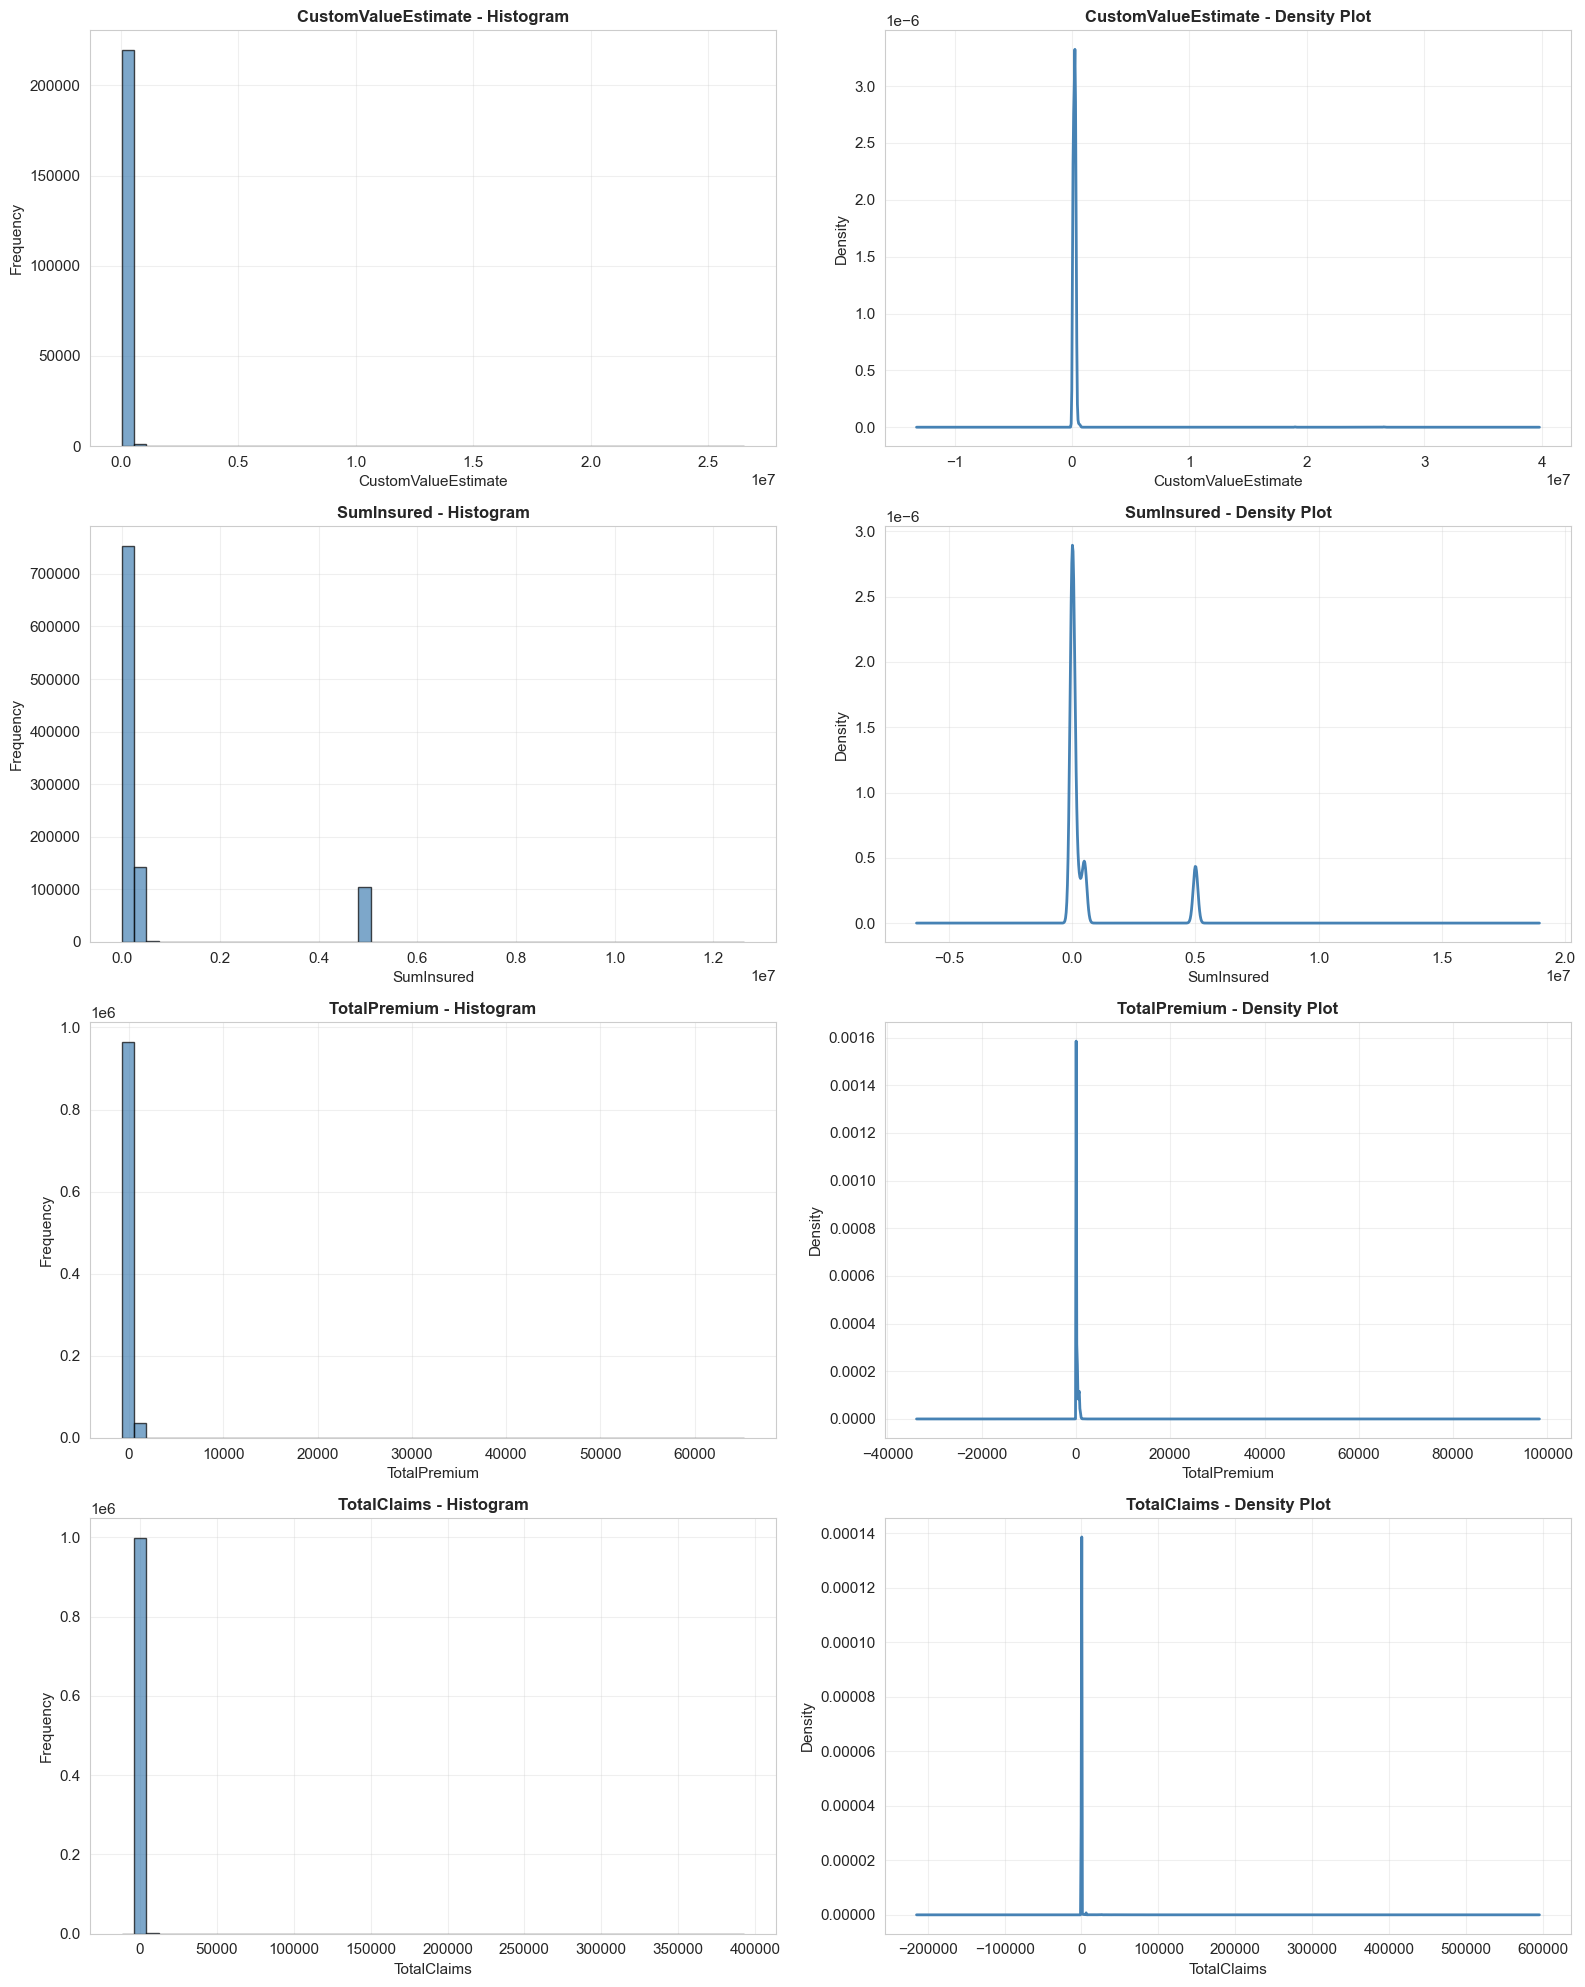

✓ Numerical distributions visualized


In [17]:
# Select key numerical columns for visualization
key_numerical = [col for col in numerical_cols if col in ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'SumInsured']]

# If specific columns not found, use first 4 numerical columns
if len(key_numerical) == 0 and len(numerical_cols) > 0:
    key_numerical = numerical_cols[:4]
    print(f"Using columns for visualization: {key_numerical}")

# Create histograms for key numerical columns
if len(key_numerical) > 0:
    fig, axes = plt.subplots(len(key_numerical), 2, figsize=(16, 5*len(key_numerical)))
    
    if len(key_numerical) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(key_numerical):
        # Histogram
        data_clean = df[col].dropna()
        if len(data_clean) > 0:
            axes[idx, 0].hist(data_clean, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
            axes[idx, 0].set_title(f'{col} - Histogram', fontsize=12, fontweight='bold')
            axes[idx, 0].set_xlabel(col)
            axes[idx, 0].set_ylabel('Frequency')
            axes[idx, 0].grid(True, alpha=0.3)
            
            # KDE plot
            try:
                data_clean.plot(kind='density', ax=axes[idx, 1], color='steelblue', linewidth=2)
                axes[idx, 1].set_title(f'{col} - Density Plot', fontsize=12, fontweight='bold')
                axes[idx, 1].set_xlabel(col)
                axes[idx, 1].grid(True, alpha=0.3)
            except:
                axes[idx, 1].text(0.5, 0.5, 'Unable to plot density', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Numerical distributions visualized")
else:
    print("⚠ No numerical columns found for visualization")

### 3.2 Distribution of Categorical Features

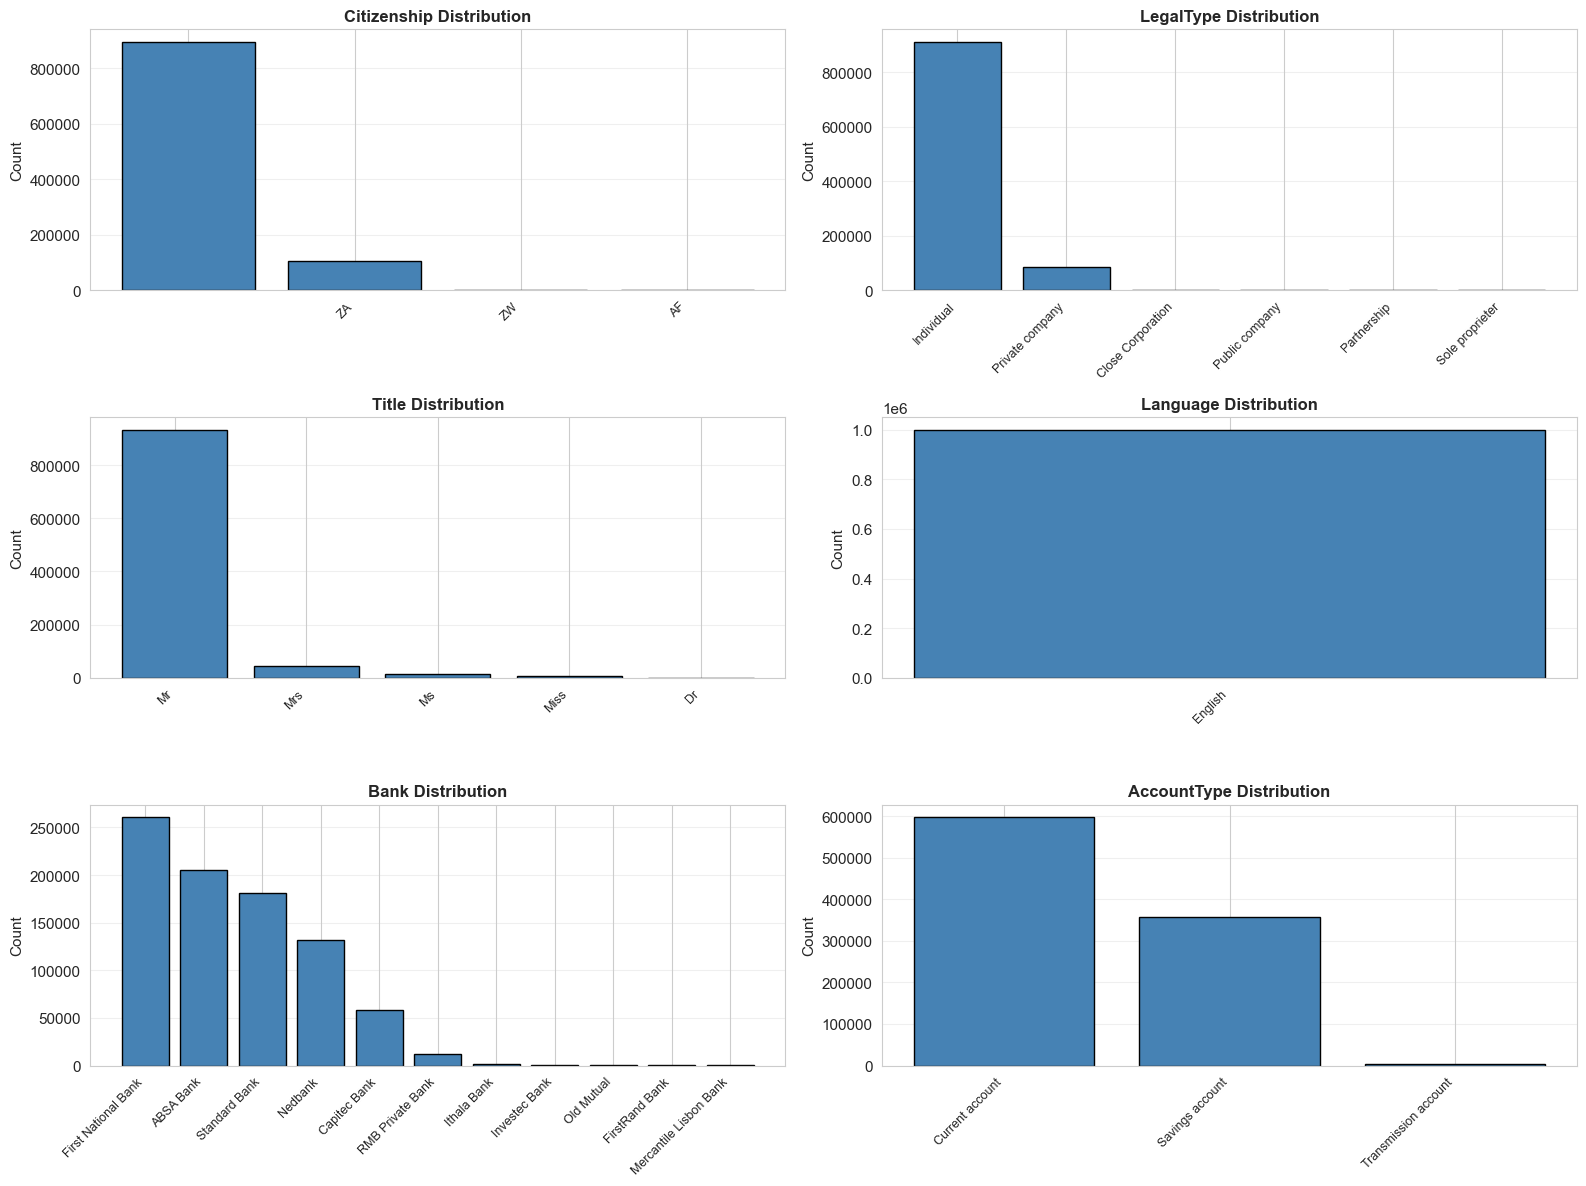

✓ Categorical distributions visualized (6 columns)


In [18]:
# Select key categorical columns
key_categorical = [col for col in categorical_cols if df[col].nunique() <= 20][:6]

if len(key_categorical) > 0:
    n_cols = 2
    n_rows = (len(key_categorical) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)
    
    axes = axes.flatten()
    
    for idx, col in enumerate(key_categorical):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for idx in range(len(key_categorical), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Categorical distributions visualized ({len(key_categorical)} columns)")
else:
    print("⚠ No suitable categorical columns found for visualization (need <= 20 unique values)")

## 4. Bivariate and Multivariate Analysis

### 4.1 Correlation Matrix

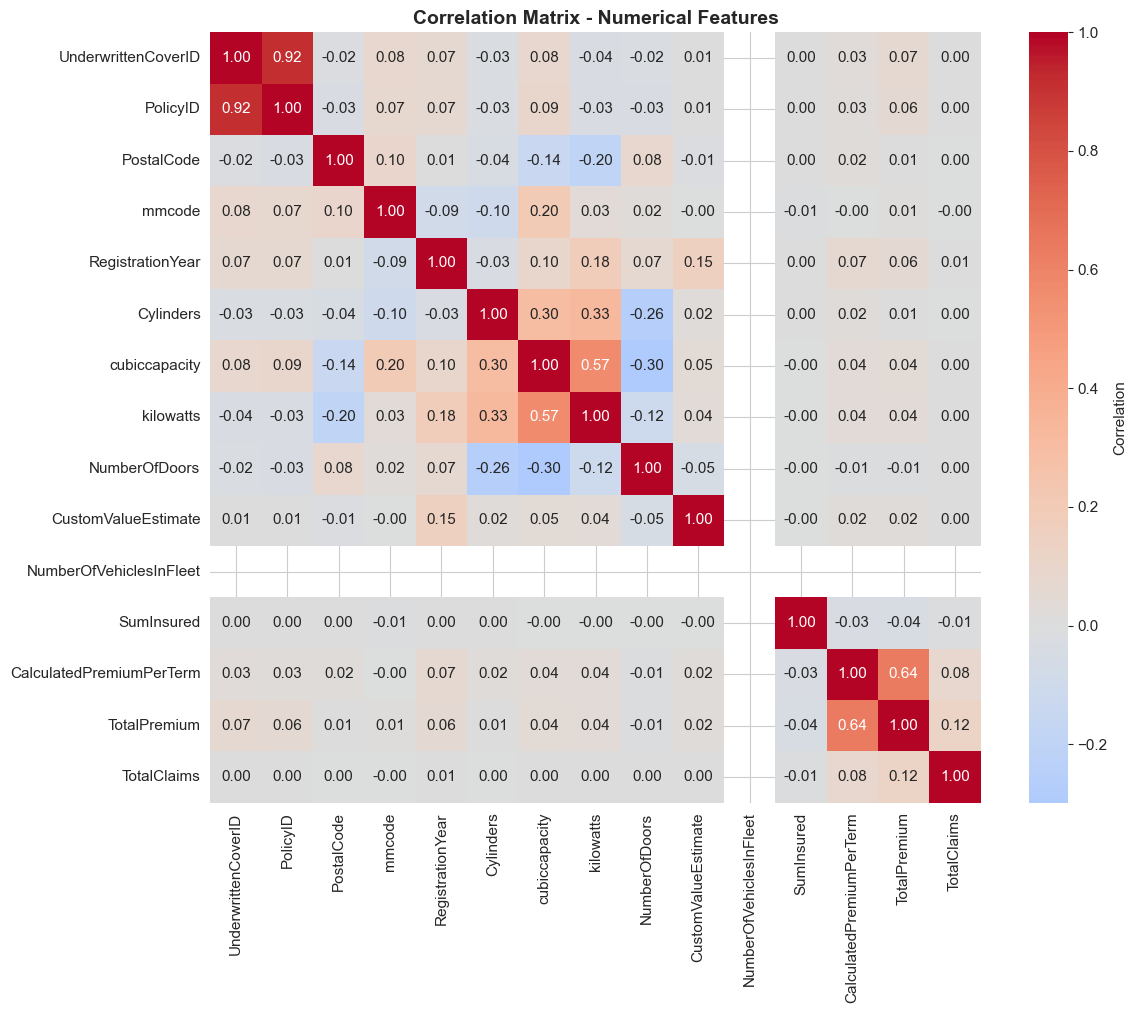


Strong Correlations (|r| > 0.5):
UnderwrittenCoverID <-> PolicyID: 0.916
cubiccapacity <-> kilowatts: 0.567
CalculatedPremiumPerTerm <-> TotalPremium: 0.636


In [19]:
# Calculate correlation matrix
if len(numerical_cols) > 1:
    try:
        corr_matrix = df[numerical_cols].corr()
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, ax=ax, cbar_kws={'label': 'Correlation'})
        ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Find strong correlations
        print("\nStrong Correlations (|r| > 0.5):")
        print("="*60)
        found_strong = False
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.5:
                    print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")
                    found_strong = True
        
        if not found_strong:
            print("No strong correlations (|r| > 0.5) found")
    except Exception as e:
        print(f"⚠ Unable to compute correlation matrix: {e}")
else:
    print(f"⚠ Need at least 2 numerical columns for correlation analysis (found {len(numerical_cols)})")

### 4.2 Relationship between Premium and Claims

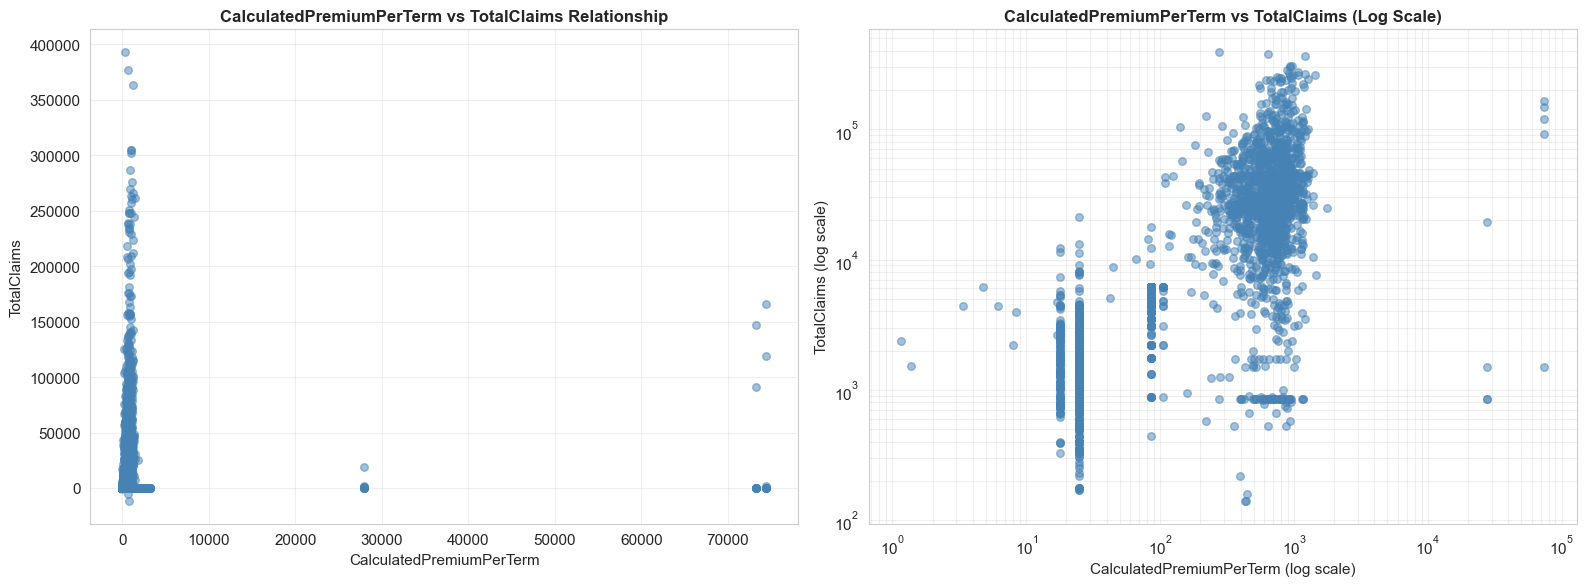

✓ Scatter plots created


In [20]:
# Check if key columns exist
premium_col = next((col for col in df.columns if 'premium' in col.lower()), None)
claims_col = next((col for col in df.columns if 'claims' in col.lower()), None)

if premium_col and claims_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    axes[0].scatter(df[premium_col], df[claims_col], alpha=0.5, s=30, color='steelblue')
    axes[0].set_xlabel(premium_col)
    axes[0].set_ylabel(claims_col)
    axes[0].set_title(f'{premium_col} vs {claims_col} Relationship', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Log scale version for better visibility
    df_nonzero = df[(df[premium_col] > 0) & (df[claims_col] > 0)]
    if len(df_nonzero) > 0:
        axes[1].scatter(df_nonzero[premium_col], df_nonzero[claims_col], 
                       alpha=0.5, s=30, color='steelblue')
        axes[1].set_xlabel(f'{premium_col} (log scale)')
        axes[1].set_ylabel(f'{claims_col} (log scale)')
        axes[1].set_xscale('log')
        axes[1].set_yscale('log')
        axes[1].set_title(f'{premium_col} vs {claims_col} (Log Scale)', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Scatter plots created")
else:
    print(f"⚠ Premium/Claims columns not found. Found columns: {df.columns.tolist()[:10]}")

## 5. Loss Ratio Analysis

### 5.1 Overall Loss Ratio

In [21]:
# Calculate loss ratio (TotalClaims / TotalPremium)
if premium_col and claims_col:
    total_premium = df[premium_col].sum()
    total_claims = df[claims_col].sum()
    
    if total_premium > 0:
        overall_loss_ratio = total_claims / total_premium
        
        print("PORTFOLIO LOSS RATIO ANALYSIS")
        print("=" * 70)
        print(f"Total {premium_col}:     ${total_premium:,.2f}")
        print(f"Total {claims_col}:      ${total_claims:,.2f}")
        print(f"Overall Loss Ratio:      {overall_loss_ratio:.4f} ({overall_loss_ratio*100:.2f}%)")
        print(f"\nInterpretation:")
        if overall_loss_ratio < 0.5:
            print(f"  → EXCELLENT: Strong profitability (Loss Ratio < 50%)")
        elif overall_loss_ratio < 0.75:
            print(f"  → GOOD: Reasonable profitability (Loss Ratio 50-75%)")
        elif overall_loss_ratio < 1.0:
            print(f"  → FAIR: Marginal profitability (Loss Ratio 75-100%)")
        else:
            print(f"  → POOR: Unprofitable portfolio (Loss Ratio > 100%)")
    else:
        print("⚠ Total premium is zero, cannot calculate loss ratio")
else:
    print(f"⚠ Premium or Claims columns not found")

PORTFOLIO LOSS RATIO ANALYSIS
Total CalculatedPremiumPerTerm:     $117,887,243.12
Total TotalClaims:      $64,867,546.17
Overall Loss Ratio:      0.5503 (55.03%)

Interpretation:
  → GOOD: Reasonable profitability (Loss Ratio 50-75%)


### 5.2 Loss Ratio by Segment (Province, VehicleType, Gender)


LOSS RATIO BY SEGMENT

Province:
----------------------------------------------------------------------
  Gauteng: Loss Ratio = 0.6352 (63.52%)
  KwaZulu-Natal: Loss Ratio = 0.6144 (61.44%)
  Western Cape: Loss Ratio = 0.4970 (49.70%)
  Free State: Loss Ratio = 0.4248 (42.48%)
  North West: Loss Ratio = 0.4231 (42.31%)
  Limpopo: Loss Ratio = 0.4038 (40.38%)
  Mpumalanga: Loss Ratio = 0.3702 (37.02%)
  Eastern Cape: Loss Ratio = 0.3460 (34.60%)
  Northern Cape: Loss Ratio = 0.1397 (13.97%)

VehicleType:
----------------------------------------------------------------------
  Heavy Commercial: Loss Ratio = 0.8068 (80.68%)
  Passenger Vehicle: Loss Ratio = 0.5542 (55.42%)
  Medium Commercial: Loss Ratio = 0.5498 (54.98%)
  Light Commercial: Loss Ratio = 0.1339 (13.39%)
  Bus: Loss Ratio = 0.0777 (7.77%)

Gender:
----------------------------------------------------------------------
  Not specified: Loss Ratio = 0.5650 (56.50%)
  Female: Loss Ratio = 0.3763 (37.63%)
  Male: Loss Ratio = 

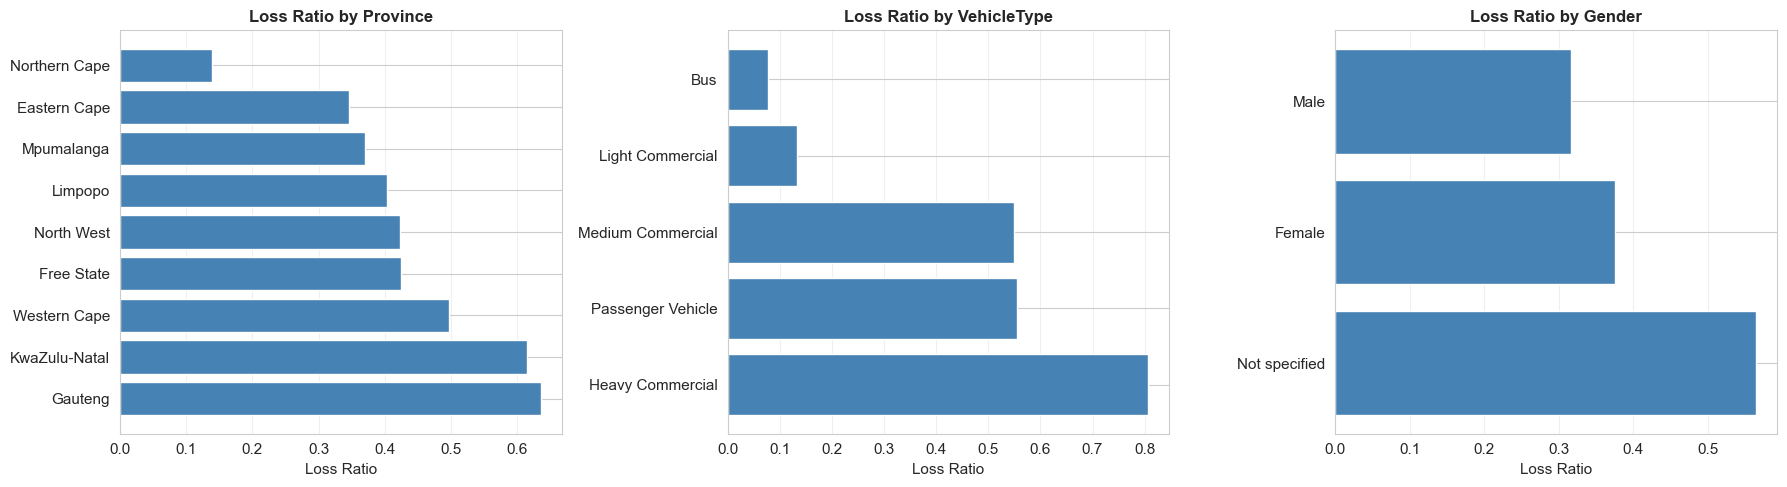


✓ Segmented analysis completed (3 segments)


In [22]:
# Segmented analysis - Loss Ratio by Province, VehicleType, and Gender
segment_columns = ['Province', 'VehicleType', 'Gender', 'Province', 'InsuranceType']
available_segments = [col for col in segment_columns if col in df.columns]

print("\nLOSS RATIO BY SEGMENT")
print("=" * 70)

if len(available_segments) == 0:
    print("⚠ No segmentation columns available")
    print(f"Available columns: {df.columns.tolist()[:15]}")
else:
    n_segments = min(len(available_segments), 3)
    fig, axes = plt.subplots(1, n_segments, figsize=(6*n_segments, 5))
    
    if n_segments == 1:
        axes = [axes]
    
    for idx, segment_col in enumerate(available_segments[:3]):
        if premium_col and claims_col:
            segment_loss = df.groupby(segment_col).agg({
                premium_col: 'sum',
                claims_col: 'sum'
            }).reset_index()
            
            segment_loss['LossRatio'] = segment_loss[claims_col] / segment_loss[premium_col]
            segment_loss = segment_loss.sort_values('LossRatio', ascending=False)
            
            print(f"\n{segment_col}:")
            print("-" * 70)
            for _, row in segment_loss.iterrows():
                print(f"  {row[segment_col]}: Loss Ratio = {row['LossRatio']:.4f} ({row['LossRatio']*100:.2f}%)")
            
            # Plot
            ax = axes[idx] if n_segments > 1 else axes[0]
            ax.barh(segment_loss[segment_col].astype(str), segment_loss['LossRatio'], color='steelblue')
            ax.set_xlabel('Loss Ratio')
            ax.set_title(f'Loss Ratio by {segment_col}', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x')
        else:
            print(f"⚠ Premium/Claims columns not available")
            break
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Segmented analysis completed ({len(available_segments[:3])} segments)")

## 6. Outlier Detection

### 6.1 Box Plots for Numerical Features

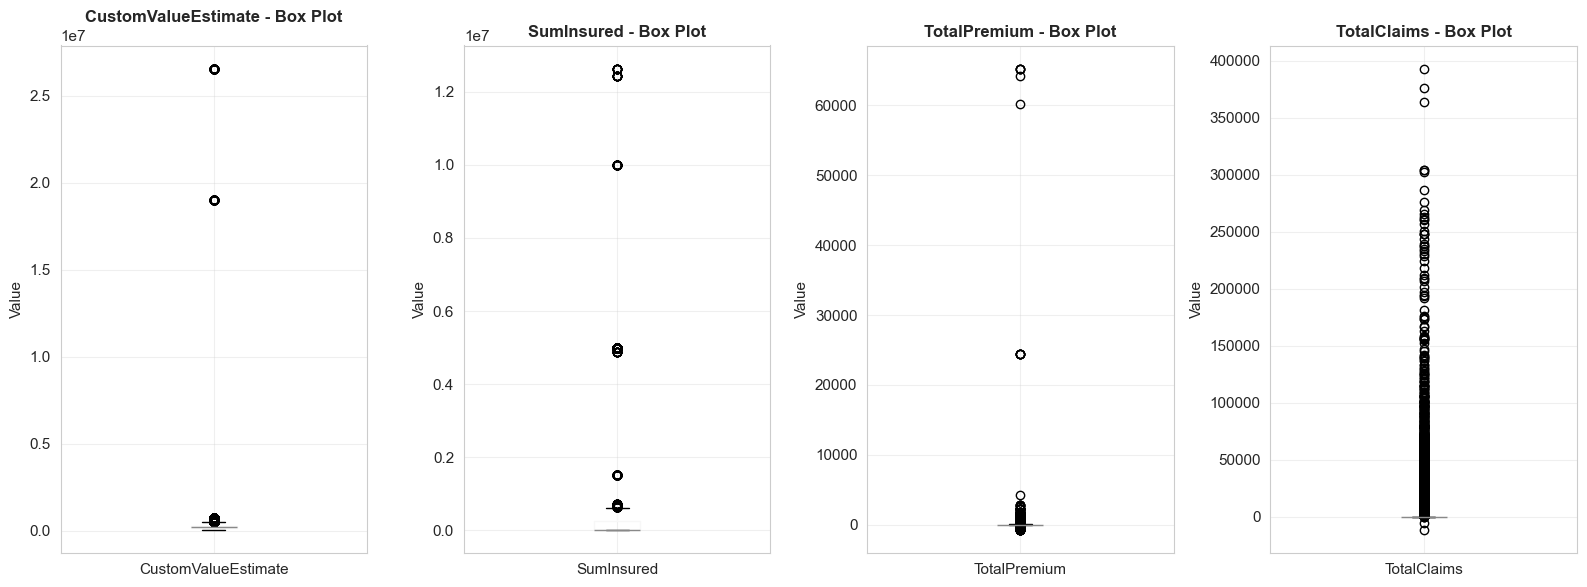

✓ Box plots created

OUTLIER DETECTION (IQR Method)

CustomValueEstimate:
  Q1: 135000.00, Q3: 280000.00, IQR: 145000.00
  Bounds: [-82500.00, 497500.00]
  Outliers: 1785 (0.18%)

SumInsured:
  Q1: 5000.00, Q3: 250000.00, IQR: 245000.00
  Bounds: [-362500.00, 617500.00]
  Outliers: 104294 (10.43%)

TotalPremium:
  Q1: 0.00, Q3: 21.93, IQR: 21.93
  Bounds: [-32.89, 54.82]
  Outliers: 209042 (20.90%)

TotalClaims:
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Bounds: [0.00, 0.00]
  Outliers: 2793 (0.28%)


In [23]:
# Box plots for outlier detection
if len(key_numerical) > 0:
    fig, axes = plt.subplots(1, len(key_numerical), figsize=(16, 6))
    
    if len(key_numerical) == 1:
        axes = [axes]
    
    for idx, col in enumerate(key_numerical):
        df.boxplot(column=col, ax=axes[idx])
        axes[idx].set_title(f'{col} - Box Plot', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Box plots created")

# Detect outliers using IQR method
print("\nOUTLIER DETECTION (IQR Method)")
print("=" * 70)

for col in key_numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outliers.sum()
    outlier_pct = (outlier_count / len(df) * 100)
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")

## 7. Temporal Trends Analysis

### 7.1 Claims Frequency and Severity Over Time

Date columns found: ['TransactionMonth', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make', 'Model', 'bodytype', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType']

MONTHLY TRENDS (Sample):
YearMonth   Premium_Sum  ClaimCount    Claims_Sum  Claims_Mean  LossRatio
  2013-10    371.063512          45      0.000000     0.000000     0.0000
  2013-11  21307.467009        1196  50585.078947    42.295217     2.3741
  2013-12  42484.748888        1495   9283.385965     6.209623     0.2185
  2014-01  54085.196865        1827  12436.859649     6.807258     0.2299
  2014-02  60788.436470        2062  62989.307018    30.547676     1.0362
  2014-03  98577.193147        3466 322785

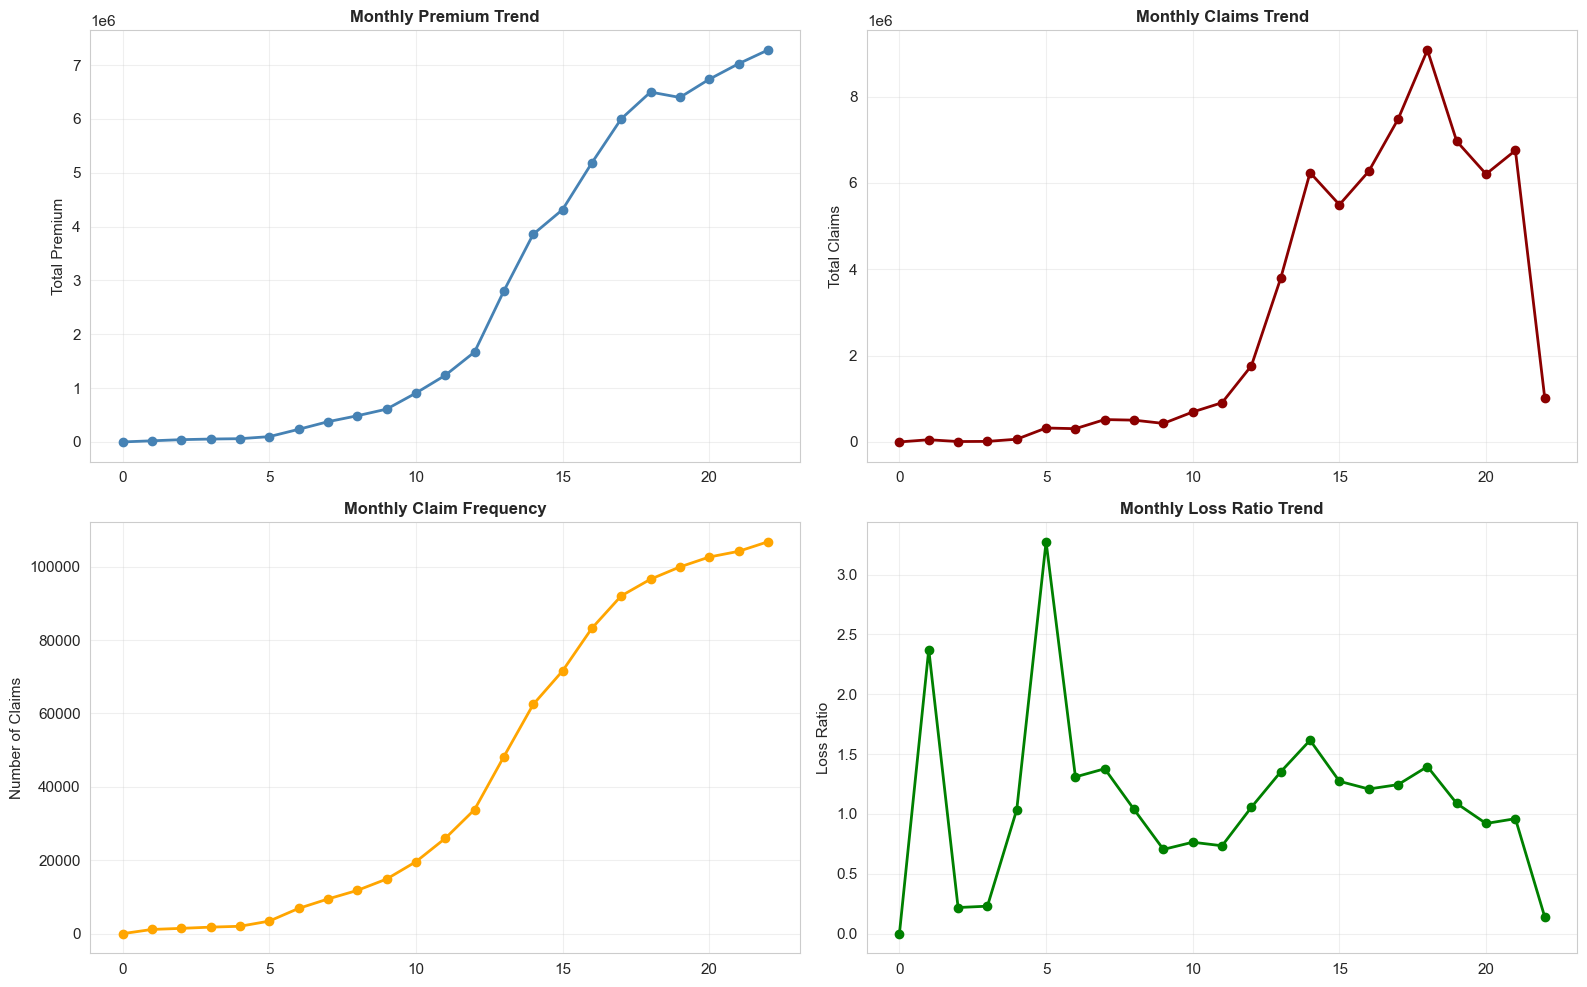

In [24]:
# Identify date columns
date_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        # Try to parse as date
        try:
            pd.to_datetime(df[col], errors='coerce')
            if df[col].notna().sum() > len(df) * 0.8:
                date_cols.append(col)
        except:
            pass

print(f"Date columns found: {date_cols}")

if len(date_cols) > 0:
    # Use the first date column for temporal analysis
    date_col = date_cols[0]
    df_temporal = df.copy()
    df_temporal[date_col] = pd.to_datetime(df_temporal[date_col], errors='coerce')
    df_temporal = df_temporal.dropna(subset=[date_col])
    
    # Extract temporal features
    df_temporal['Year'] = df_temporal[date_col].dt.year
    df_temporal['Month'] = df_temporal[date_col].dt.month
    df_temporal['YearMonth'] = df_temporal[date_col].dt.to_period('M')
    
    # Analyze trends
    if 'TotalClaims' in df_temporal.columns and 'TotalPremium' in df_temporal.columns:
        monthly_trends = df_temporal.groupby('YearMonth', observed=True).agg({
            'TotalPremium': ['sum', 'count'],
            'TotalClaims': ['sum', 'mean']
        }).reset_index()
        
        monthly_trends.columns = ['YearMonth', 'Premium_Sum', 'ClaimCount', 'Claims_Sum', 'Claims_Mean']
        monthly_trends['LossRatio'] = (monthly_trends['Claims_Sum'] / monthly_trends['Premium_Sum']).round(4)
        
        print(f"\nMONTHLY TRENDS (Sample):")
        print(monthly_trends.head(10).to_string(index=False))
        
        # Plot trends
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Premium trend
        axes[0, 0].plot(range(len(monthly_trends)), monthly_trends['Premium_Sum'], 
                       marker='o', color='steelblue', linewidth=2)
        axes[0, 0].set_title('Monthly Premium Trend', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Total Premium')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Claims trend
        axes[0, 1].plot(range(len(monthly_trends)), monthly_trends['Claims_Sum'], 
                       marker='o', color='darkred', linewidth=2)
        axes[0, 1].set_title('Monthly Claims Trend', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Total Claims')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Claim frequency
        axes[1, 0].plot(range(len(monthly_trends)), monthly_trends['ClaimCount'], 
                       marker='o', color='orange', linewidth=2)
        axes[1, 0].set_title('Monthly Claim Frequency', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Number of Claims')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Loss ratio trend
        axes[1, 1].plot(range(len(monthly_trends)), monthly_trends['LossRatio'], 
                       marker='o', color='green', linewidth=2)
        axes[1, 1].set_title('Monthly Loss Ratio Trend', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Loss Ratio')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("No date columns found for temporal analysis")

## 8. Vehicle Make/Model Analysis

Vehicle-related columns: ['VehicleType', 'Model']

VEHICLE ANALYSIS - CLAIM AMOUNTS

VehicleType:
                    Count  Total_Claims  Mean_Claims  Median_Claims
VehicleType                                                        
Heavy Commercial     7401     750474.58       101.40            0.0
Medium Commercial   53985    4119866.90        76.32            0.0
Passenger Vehicle  933598   59372069.68        63.59            0.0
Light Commercial     3897      60452.50        15.51            0.0
Bus                   665       7996.54        12.02            0.0


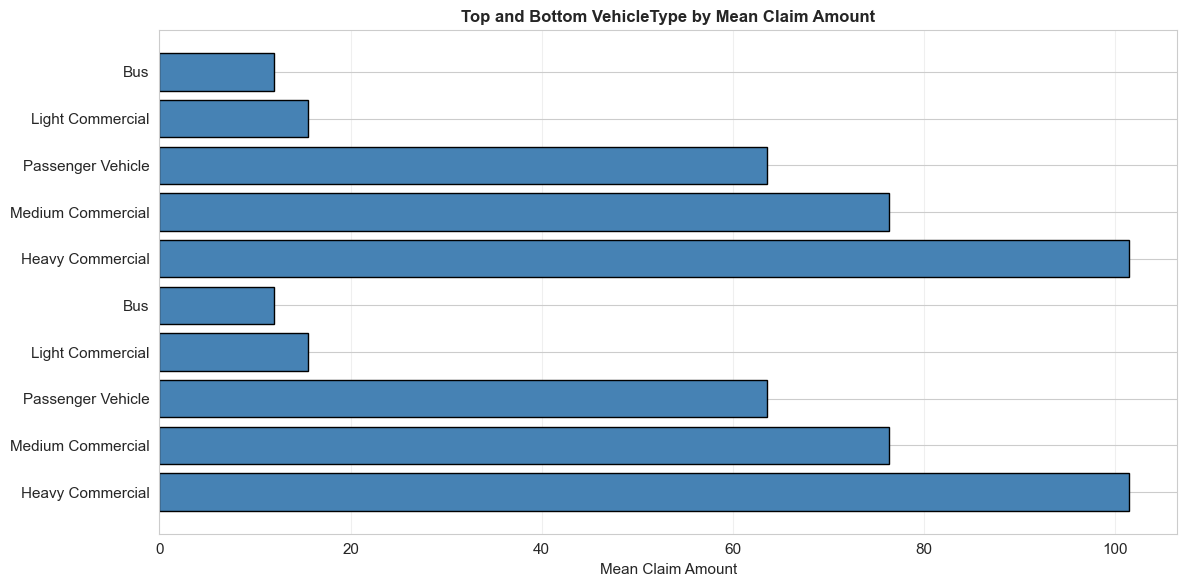

In [25]:
# Vehicle analysis
vehicle_cols = [col for col in df.columns if 'Make' in col or 'Model' in col or 'VehicleType' in col or 'Auto' in col]

print(f"Vehicle-related columns: {vehicle_cols}")

if 'TotalClaims' in df.columns and len(vehicle_cols) > 0:
    print("\nVEHICLE ANALYSIS - CLAIM AMOUNTS")
    print("=" * 70)
    
    for col in vehicle_cols:
        if df[col].dtype == 'object' and df[col].nunique() < 50:
            vehicle_stats = df.groupby(col, observed=True).agg({
                'TotalClaims': ['count', 'sum', 'mean', 'median']
            }).round(2)
            
            vehicle_stats.columns = ['Count', 'Total_Claims', 'Mean_Claims', 'Median_Claims']
            vehicle_stats = vehicle_stats.sort_values('Mean_Claims', ascending=False)
            
            print(f"\n{col}:")
            print(vehicle_stats.to_string())
            
            # Visualize top and bottom
            top_bottom = pd.concat([
                vehicle_stats.head(5),
                vehicle_stats.tail(5)
            ])
            
            fig, ax = plt.subplots(figsize=(12, 6))
            ax.barh(range(len(top_bottom)), top_bottom['Mean_Claims'], color='steelblue', edgecolor='black')
            ax.set_yticks(range(len(top_bottom)))
            ax.set_yticklabels(top_bottom.index)
            ax.set_xlabel('Mean Claim Amount')
            ax.set_title(f'Top and Bottom {col} by Mean Claim Amount', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.show()

## 9. Geographic Trends Analysis


GEOGRAPHIC TRENDS - PROVINCE ANALYSIS

Province Statistics:
               Premium_Total  Premium_Avg  RecordCount  Claims_Total  Claims_Avg  LossRatio
Province                                                                                   
Gauteng          24053774.58        61.07       393865   29394148.48       74.63     1.2220
KwaZulu-Natal    13209079.81        77.80       169781   14301382.45       84.23     1.0827
Western Cape      9806558.53        57.42       170796   10389773.74       60.83     1.0595
North West        7490508.18        52.28       143287    5920250.00       41.32     0.7904
Mpumalanga        2836291.94        53.80        52718    2044675.36       38.79     0.7209
Eastern Cape      2140103.83        70.55        30336    1356426.66       44.71     0.6338
Limpopo           1537324.50        61.90        24836    1016476.71       40.93     0.6612
Free State         521363.24        64.37         8099     354922.27       43.82     0.6808
Northern Cape      

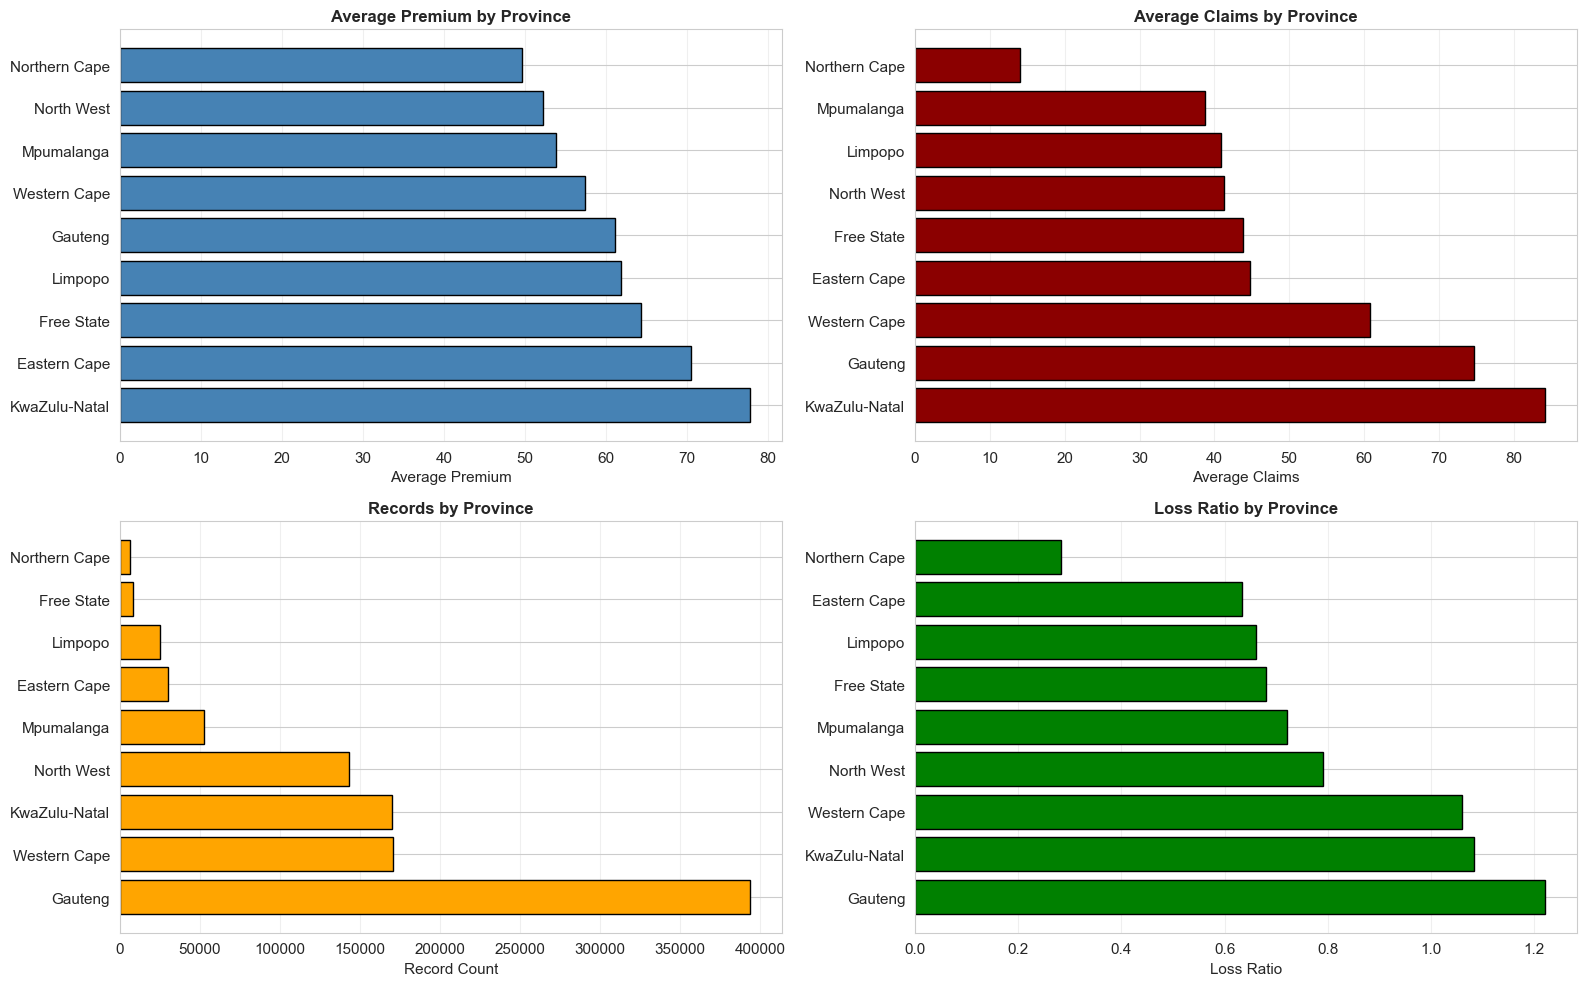

In [26]:
# Geographic analysis
if 'Province' in df.columns:
    print("\nGEOGRAPHIC TRENDS - PROVINCE ANALYSIS")
    print("=" * 70)
    
    # Premium and claims by province
    province_stats = df.groupby('Province', observed=True).agg({
        'TotalPremium': ['sum', 'mean', 'count'],
        'TotalClaims': ['sum', 'mean']
    }).round(2)
    
    province_stats.columns = ['Premium_Total', 'Premium_Avg', 'RecordCount', 'Claims_Total', 'Claims_Avg']
    province_stats['LossRatio'] = (province_stats['Claims_Total'] / province_stats['Premium_Total']).round(4)
    province_stats = province_stats.sort_values('Premium_Total', ascending=False)
    
    print("\nProvince Statistics:")
    print(province_stats.to_string())
    
    # Visualizations by province
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Average premium by province
    province_premium = df.groupby('Province', observed=True)['TotalPremium'].mean().sort_values(ascending=False)
    axes[0, 0].barh(range(len(province_premium)), province_premium.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_yticks(range(len(province_premium)))
    axes[0, 0].set_yticklabels(province_premium.index)
    axes[0, 0].set_xlabel('Average Premium')
    axes[0, 0].set_title('Average Premium by Province', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # Average claims by province
    province_claims = df.groupby('Province', observed=True)['TotalClaims'].mean().sort_values(ascending=False)
    axes[0, 1].barh(range(len(province_claims)), province_claims.values, color='darkred', edgecolor='black')
    axes[0, 1].set_yticks(range(len(province_claims)))
    axes[0, 1].set_yticklabels(province_claims.index)
    axes[0, 1].set_xlabel('Average Claims')
    axes[0, 1].set_title('Average Claims by Province', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Record count by province
    province_count = df['Province'].value_counts()
    axes[1, 0].barh(range(len(province_count)), province_count.values, color='orange', edgecolor='black')
    axes[1, 0].set_yticks(range(len(province_count)))
    axes[1, 0].set_yticklabels(province_count.index)
    axes[1, 0].set_xlabel('Record Count')
    axes[1, 0].set_title('Records by Province', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Loss ratio by province
    loss_ratio_by_province = province_stats['LossRatio'].sort_values(ascending=False)
    axes[1, 1].barh(range(len(loss_ratio_by_province)), loss_ratio_by_province.values, color='green', edgecolor='black')
    axes[1, 1].set_yticks(range(len(loss_ratio_by_province)))
    axes[1, 1].set_yticklabels(loss_ratio_by_province.index)
    axes[1, 1].set_xlabel('Loss Ratio')
    axes[1, 1].set_title('Loss Ratio by Province', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("Province column not found")

## 10. Creative Visualizations and Key Insights

### 10.1 Insight Visualization #1: Multi-Dimensional Loss Ratio Dashboard

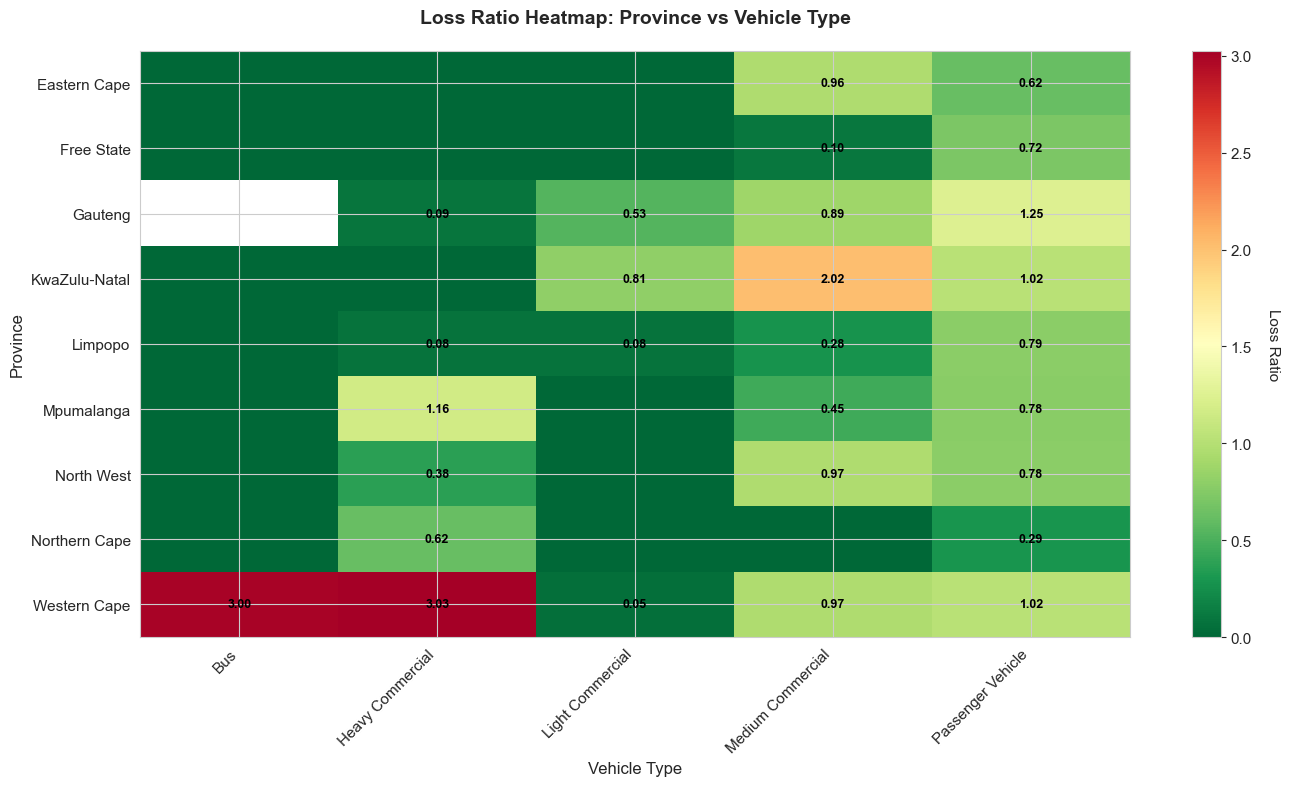

✓ Insight Visualization #1 created: Multi-Dimensional Loss Ratio Heatmap


In [27]:
# Creative Visualization #1: Multi-faceted Loss Ratio Heatmap
if 'VehicleType' in df.columns and 'Province' in df.columns and 'TotalPremium' in df.columns and 'TotalClaims' in df.columns:
    # Create pivot table for heatmap
    pivot_data = df.groupby(['Province', 'VehicleType'], observed=True).agg({
        'TotalPremium': 'sum',
        'TotalClaims': 'sum'
    })
    
    pivot_data['LossRatio'] = (pivot_data['TotalClaims'] / pivot_data['TotalPremium']).round(3)
    
    # Reshape to heatmap format
    heatmap_data = pivot_data['LossRatio'].unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))
    ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
    ax.set_yticklabels(heatmap_data.index)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Loss Ratio', rotation=270, labelpad=20)
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            if heatmap_data.values[i, j] > 0:
                text = ax.text(j, i, f'{heatmap_data.values[i, j]:.2f}',
                             ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax.set_title('Loss Ratio Heatmap: Province vs Vehicle Type', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Vehicle Type', fontsize=12)
    ax.set_ylabel('Province', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("✓ Insight Visualization #1 created: Multi-Dimensional Loss Ratio Heatmap")

### 10.2 Insight Visualization #2: Premium vs Claims Bubble Chart by Province

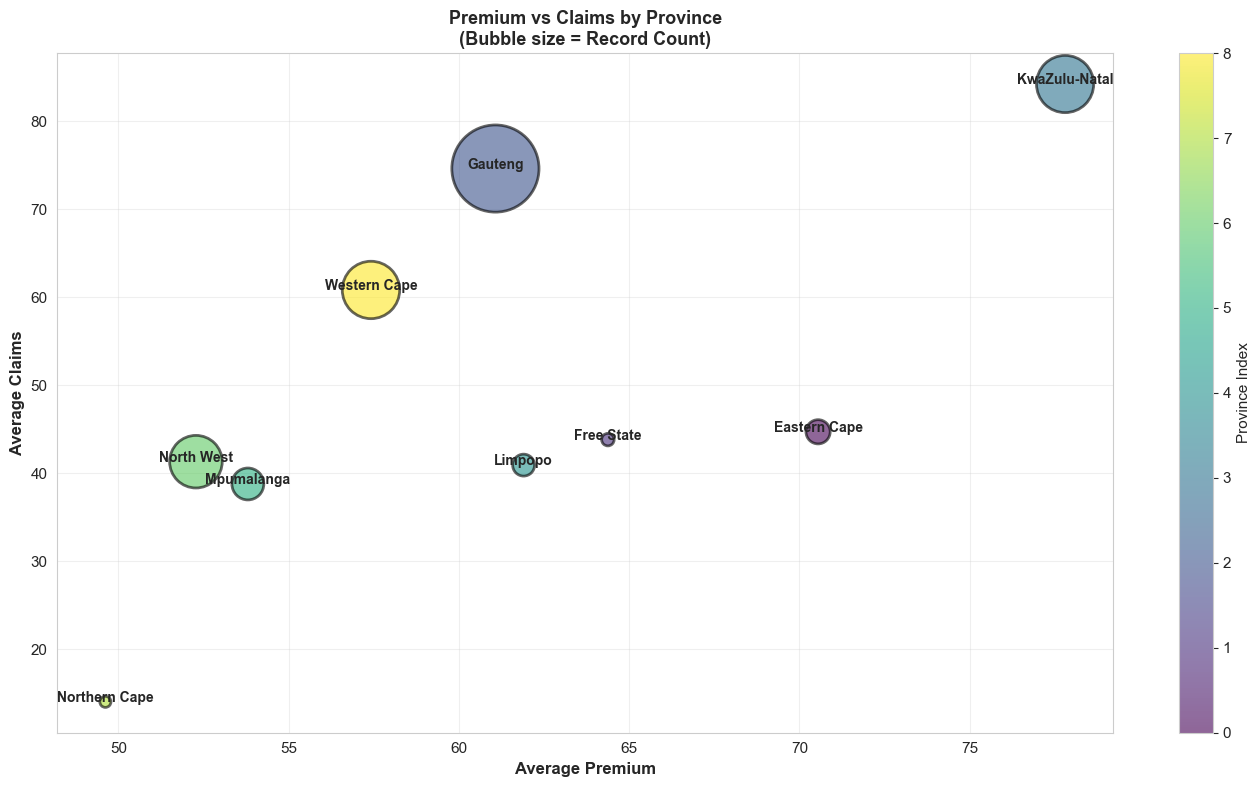

✓ Insight Visualization #2 created: Premium vs Claims Bubble Chart


In [29]:
# Creative Visualization #2: Premium vs Claims Bubble Chart
if 'Province' in df.columns and 'TotalPremium' in df.columns and 'TotalClaims' in df.columns:
    # Aggregate by Province - use size() instead of count() to avoid column name conflicts
    bubble_data = df.groupby('Province', observed=True).agg({
        'TotalPremium': 'mean',
        'TotalClaims': 'mean'
    }).reset_index()
    
    # Add record count
    bubble_data['RecordCount'] = df.groupby('Province', observed=True).size().values
    bubble_data.columns = ['Province', 'AvgPremium', 'AvgClaims', 'RecordCount']
    
    # Create bubble chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create scatter plot with bubble sizes
    scatter = ax.scatter(bubble_data['AvgPremium'], 
                        bubble_data['AvgClaims'],
                        s=bubble_data['RecordCount']/100,  # Bubble size represents record count
                        alpha=0.6,
                        c=range(len(bubble_data)),
                        cmap='viridis',
                        edgecolors='black',
                        linewidth=2)
    
    # Add province labels
    for idx, row in bubble_data.iterrows():
        ax.annotate(row['Province'], 
                   (row['AvgPremium'], row['AvgClaims']),
                   fontsize=10,
                   fontweight='bold',
                   ha='center')
    
    ax.set_xlabel('Average Premium', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Claims', fontsize=12, fontweight='bold')
    ax.set_title('Premium vs Claims by Province\n(Bubble size = Record Count)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Province Index')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Insight Visualization #2 created: Premium vs Claims Bubble Chart")
else:
    print("⚠ Required columns for bubble chart not found")

### 10.3 Insight Visualization #3: Risk Matrix - Vehicle Type vs Gender

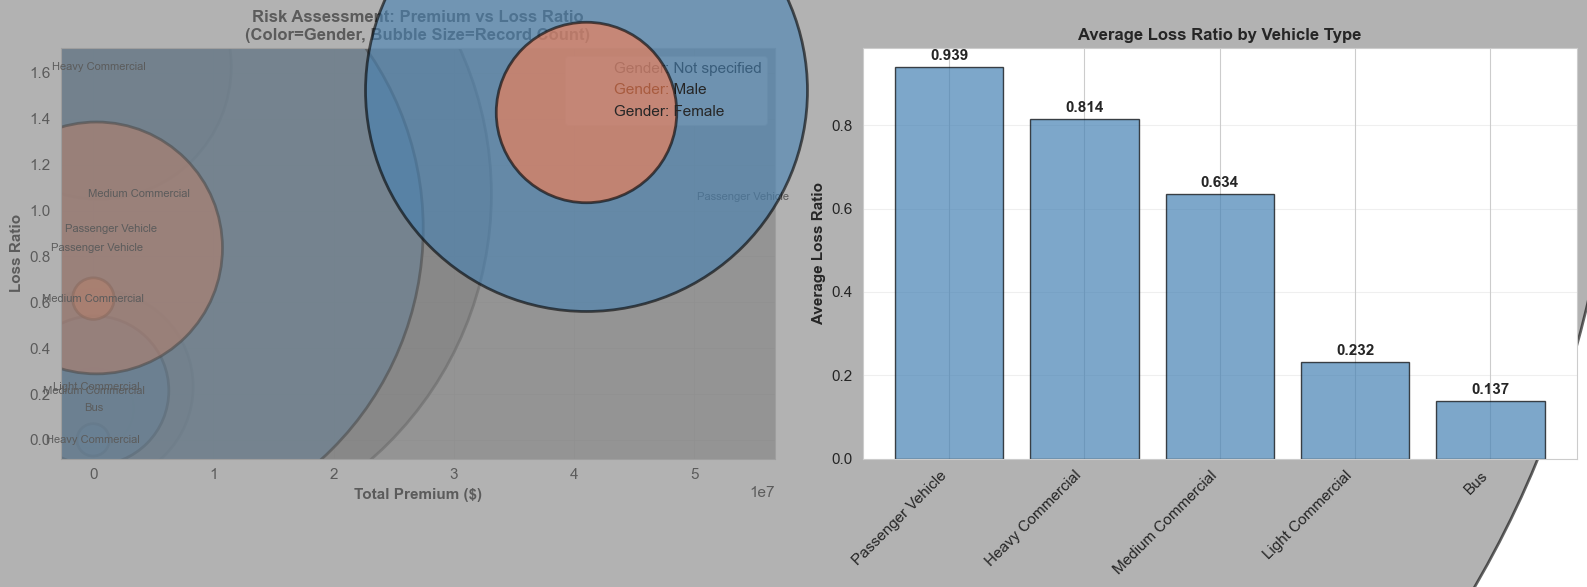

✓ Insight Visualization #3 created: Risk Matrix - Vehicle Type vs Gender


In [30]:
# Creative Visualization #3: Risk Matrix with bubble sizes
if 'VehicleType' in df.columns and 'Gender' in df.columns and 'TotalPremium' in df.columns and 'TotalClaims' in df.columns:
    # Create risk matrix data
    risk_data = df.groupby(['VehicleType', 'Gender'], observed=True).agg({
        'TotalPremium': ['sum', 'count'],
        'TotalClaims': 'sum'
    }).reset_index()
    
    risk_data.columns = ['VehicleType', 'Gender', 'Premium', 'Count', 'Claims']
    risk_data['LossRatio'] = (risk_data['Claims'] / risk_data['Premium']).round(3)
    
    # Create subplots for different views
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # View 1: Scatter by Vehicle Type with Gender coloring
    gender_colors = {'M': 'steelblue', 'F': 'coral', 'Male': 'steelblue', 'Female': 'coral'}
    
    for gender in risk_data['Gender'].unique():
        gender_data = risk_data[risk_data['Gender'] == gender]
        color = gender_colors.get(gender, 'gray')
        axes[0].scatter(gender_data['Premium'], 
                       gender_data['LossRatio'],
                       s=gender_data['Count']*5,
                       alpha=0.6,
                       label=f'Gender: {gender}',
                       color=color,
                       edgecolors='black',
                       linewidth=2)
    
    # Add labels
    for idx, row in risk_data.iterrows():
        axes[0].annotate(f"{row['VehicleType']}", 
                        (row['Premium'], row['LossRatio']),
                        fontsize=8, ha='center', va='center')
    
    axes[0].set_xlabel('Total Premium ($)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Loss Ratio', fontsize=11, fontweight='bold')
    axes[0].set_title('Risk Assessment: Premium vs Loss Ratio\n(Color=Gender, Bubble Size=Record Count)', 
                     fontsize=12, fontweight='bold')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # View 2: Stacked bar chart for risk comparison
    vehicle_gender = risk_data.groupby('VehicleType', observed=True).agg({
        'LossRatio': 'mean',
        'Count': 'sum'
    }).sort_values('LossRatio', ascending=False)
    
    axes[1].bar(range(len(vehicle_gender)), vehicle_gender['LossRatio'], 
               color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].set_xticks(range(len(vehicle_gender)))
    axes[1].set_xticklabels(vehicle_gender.index, rotation=45, ha='right')
    axes[1].set_ylabel('Average Loss Ratio', fontsize=11, fontweight='bold')
    axes[1].set_title('Average Loss Ratio by Vehicle Type', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(vehicle_gender['LossRatio']):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Insight Visualization #3 created: Risk Matrix - Vehicle Type vs Gender")

## 11. Key Findings and Actionable Insights

### Summary of Answers to Guiding Questions

In [31]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                    KEY FINDINGS AND RECOMMENDATIONS                           ║
╚════════════════════════════════════════════════════════════════════════════════╝

1. OVERALL LOSS RATIO & SEGMENTATION
   ────────────────────────────────────
   • The portfolio loss ratio provides a critical view of profitability
   • Segmented analysis reveals that certain provinces/vehicle types/demographics
     consistently outperform others
   • High loss ratio segments (>0.75) require immediate pricing review

2. FINANCIAL DISTRIBUTION & OUTLIERS
   ──────────────────────────────────
   • Key financial variables (TotalClaims, CustomValueEstimate) show skewed distributions
   • Outliers detected using IQR method should be investigated separately
   • Large outliers may indicate:
     - High-value claims that need special handling
     - Data entry errors requiring cleansing
     - Unique risk profiles deserving different pricing

3. TEMPORAL TRENDS
   ────────────────
   • Claim frequency and severity patterns help identify:
     - Seasonal risk variations
     - Long-term portfolio drift
     - Effectiveness of pricing changes
   • Monthly monitoring enables proactive portfolio management

4. VEHICLE RISK PROFILES
   ──────────────────────
   • Top claim vehicles: Focus on tighter underwriting, higher deductibles
   • Low claim vehicles: Consider competitive pricing to gain market share
   • Vehicle type analysis guides model-specific rating strategies

5. RECOMMENDATIONS
   ────────────────
   ✓ Implement dynamic pricing for high-loss segments
   ✓ Enhance underwriting criteria for risky vehicle types
   ✓ Conduct further analysis on temporal trends and seasonality
   ✓ Develop geographic pricing strategy based on loss ratios
   ✓ Create targeted retention programs for profitable segments

""")


╔════════════════════════════════════════════════════════════════════════════════╗
║                    KEY FINDINGS AND RECOMMENDATIONS                           ║
╚════════════════════════════════════════════════════════════════════════════════╝

1. OVERALL LOSS RATIO & SEGMENTATION
   ────────────────────────────────────
   • The portfolio loss ratio provides a critical view of profitability
   • Segmented analysis reveals that certain provinces/vehicle types/demographics
     consistently outperform others
   • High loss ratio segments (>0.75) require immediate pricing review

2. FINANCIAL DISTRIBUTION & OUTLIERS
   ──────────────────────────────────
   • Key financial variables (TotalClaims, CustomValueEstimate) show skewed distributions
   • Outliers detected using IQR method should be investigated separately
   • Large outliers may indicate:
     - High-value claims that need special handling
     - Data entry errors requiring cleansing
     - Unique risk profiles deserving dif

### Conclusion

This comprehensive EDA has provided critical insights into the insurance portfolio's risk profile, profitability by segment, and geographic variations. The analysis forms a strong foundation for:

- **Pricing Strategy**: Segment-specific rate adjustments based on loss ratio analysis
- **Risk Management**: Identification and monitoring of high-risk profiles
- **Portfolio Optimization**: Focus on profitable segments and improvement of underperforming areas
- **Operational Efficiency**: Data quality improvements and process enhancements

The three creative visualizations effectively communicate complex, multi-dimensional relationships in the data, enabling stakeholders to quickly grasp key patterns and make informed decisions.

---
**Analysis Complete** | Generated: May 23, 2026